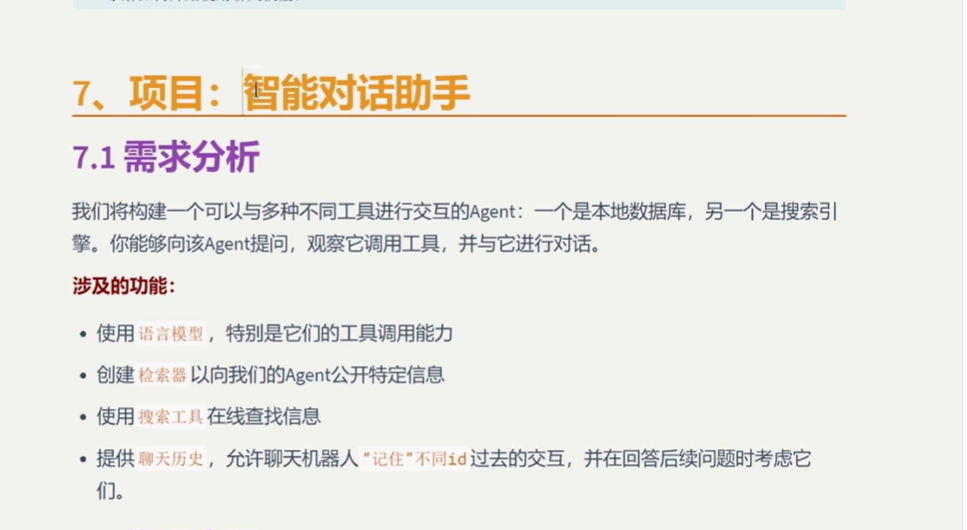

1.定义工具

In [ ]:
import os 
from langchain_community.tools.tavily_search import TavilySearchResults
import dotenv

#加载.env文件
dotenv.load_dotenv()
#定义Tavily_key 密钥
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
#构建tavily搜索工具实例
search = TavilySearchResults(max_length = 1)
#执行查询
# res = search.invoke("今天承德天气怎么样")
# print(res)

[{'title': '【承德天气预报】承德天气预报7天,10天,15天 - 全国天气网', 'url': 'https://tianqi.so.com/weather/101090402', 'content': '# 全国天气网\n\n 首页\n 国内天气\n 空气质量\n 国际天气\n 景点天气\n 天气新闻\n 专业天气\n\n收藏\n\n承德\n\n[切换]\n\n当前时间：2026-04-19周日09:16\n\n空气 良西南风 5级\n\n 今天 (04-19)\n\n  西北风 6-7级\n\n 明天 (04-20)\n\n  西风 5-6级\n\n 周二 (04-21)\n\n  西风 3-5级\n\n 周三 (04-22)\n\n  南风 4-5级\n\n 周四 (04-23)\n\n  晴转多云\n\n  西南风 3-5级\n\n 周五 (04-24)\n\n  多云\n\n  9/28℃\n\n  北风 3-5级\n\n 周六 (04-25)\n\n  阴转小雨\n\n  7/17℃\n\n  南风 3-5级\n\n 周日 (04-26)\n\n  阵雨转阴\n\n  5/12℃\n\n  西南风 微风\n\n 周一 (04-27)\n\n  多云转阵雨\n\n  6/23℃\n\n  西北风 4-5级\n\n 周二 (04-28)\n\n  多云\n\n  7/23℃\n\n  西北风 3-5级\n\n 周三 (04-29)\n\n  阴\n\n  8/24℃\n\n  西风 微风\n\n 周四 (04-30)\n\n  阴\n\n  10/22℃\n\n  南风 微风\n\n 周五 (05-01)\n\n  阵雨\n\n  5/23℃\n\n  南风 微风\n\n 周六 (05-02)\n\n  多云转阴\n\n  8/22℃\n\n  西北风 微风\n\n 周日 (05-03)\n\n  阴转阵雨\n\n  11/25℃\n\n  西南风 3-5级\n\n45日天气\n\n15日天气\n\n今日天气\n\n明日天气\n\n承德市气象台2026年04月18日11时30分发布大风蓝色预警信号：预计今天下午到夜间，我市大部分地区有西南风5～6级，阵风7～8级，请注意防范。\n\n承德市气象台2026年04月18日11时30分发布大风蓝色预警信

2.定义Retriever

In [18]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import DashScopeEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
import os 
import dotenv 
#加载.env文件
dotenv.load_dotenv()
#1.提供一个大模型
os.environ['DASHCOPE_API_KEY'] = os.getenv("DASHSCOPE_API_KEY")
embedding_model = DashScopeEmbeddings(
    model = "text-embedding-v3",
)
#2.加载html内容为一个文档对象
loader = WebBaseLoader("https://zh.wikipedia.org/wiki/%E7%8C%AB")
docs = loader.load()
# print(docs)

#3.对文档进行切分
splitter =RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 200,
)
documents = splitter.split_documents(docs)

#4.向量化 得到向量数据库对象
vector = FAISS.from_documents(documents,embedding_model)
#5.创建检索器
retriever = vector.as_retriever()
#6.执行检索
# question = retriever.invoke("猫的特征")
# print(question)

3.创建工具，工具集

In [19]:
from langchain_core.tools.retriever import create_retriever_tool
#创建一个工具来检索文档
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name="wiki_search",
    description="搜索维基百科"
)
#创建工具集
tools = [search,retriever_tool]

4.语言模型调用工具

In [ ]:
from langchain_community.chat_models import ChatTongyi
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

#获取大模型
model = ChatTongyi(
    model_name = "qwen-flash",
)

#模型绑定工具
model_with_tools = model.bind_tools(tools)

#根据输入自动调用工具
messages = [HumanMessage(content="今天承德天气怎么样")]
response = model_with_tools.invoke(messages)
# print(f"ContentString:{response.content}")
# print(f"ToolName:{response.tool_calls}")

ContentString:
ToolName:[{'name': 'tavily_search_results_json', 'args': {'query': '今天承德天气怎么样'}, 'id': 'call_36bf7860563e4be189f921', 'type': 'tool_call'}]


5.创建Agent程序（使用通用方式）

In [ ]:
from langchain_classic import hub
prompt = hub.pull("hwchase17/openai-functions-agent")

# print(prompt.messages)


In [26]:
from langchain_classic.agents.tool_calling_agent.base import create_tool_calling_agent
from langchain_classic.agents.agent import AgentExecutor
#创建agent对象
agent = create_tool_calling_agent(llm=model,tools=tools,prompt=prompt)

#创建AgentExecutor对象
agent_executor = AgentExecutor(agent=agent,tools=tools,verbose=True)

6.运行Agent

In [51]:
# print(agent_executor.invoke({"input":"猫的特征"}))

In [52]:
# print(agent_executor.invoke({"input":"今天承德天气怎么样"}))

7.添加记忆

In [ ]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory


store = {}

#调去指定session_id对应的memory
def get_session_history(session_id: str) -> BaseChatMessageHistory:
    if session_id not in store:
        store[session_id] = ChatMessageHistory()
    return store[session_id]

agent_with_chat_history = RunnableWithMessageHistory(
    runnable=agent_executor,
    get_session_history=get_session_history,
    input_messages_key="input",
    history_messages_key="chat_history",
)

response = agent_with_chat_history.invoke(
    {"input": "Hi, 我的名字是Cyber"},
    config={"configurable": {"session_id": "123"}},
)

print(response)



> Entering new AgentExecutor chain...
Hello Cyber! How can I assist you today?

> Finished chain.
{'input': 'Hi, 我的名字是Cyber', 'chat_history': [], 'output': 'Hello Cyber! How can I assist you today?'}


In [46]:
response = agent_with_chat_history.invoke(
    {"input":"我叫什么名字"},
    config={"configurable": {"session_id": "123"}}
)
print(response)



> Entering new AgentExecutor chain...
你告诉过我你的名字是 Cyber。

> Finished chain.
{'input': '我叫什么名字', 'chat_history': [HumanMessage(content='Hi, 我的名字是Cyber', additional_kwargs={}, response_metadata={}), AIMessage(content='Hello Cyber! How can I assist you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'output': '你告诉过我你的名字是 Cyber。'}


In [ ]:
response = agent_with_chat_history.invoke(
    {"input":"我叫什么名字"},
    config={"configurable": {"session_id": "456"}}
)
print(response)



> Entering new AgentExecutor chain...
我无法知道你的名字，因为您没有提供相关信息。如果您愿意，可以告诉我您的名字，我会很乐意称呼您！

> Finished chain.
{'input': '我叫什么名字', 'chat_history': [], 'output': '我无法知道你的名字，因为您没有提供相关信息。如果您愿意，可以告诉我您的名字，我会很乐意称呼您！'}


Failed to refresh cache entry hwchase17/openai-functions-agent: Connection error caused failure to GET /commits/hwchase17/openai-functions-agent/latest in LangSmith API. Please confirm your internet connection. SSLError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /commits/hwchase17/openai-functions-agent/latest (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1016)')))"))
Content-Length: None
API Key: 
Failed to refresh cache entry hwchase17/openai-functions-agent: Connection error caused failure to GET /commits/hwchase17/openai-functions-agent/latest in LangSmith API. Please confirm your internet connection. SSLError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /commits/hwchase17/openai-functions-agent/latest (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurr